# Data and Statistical Reasoning: Education and Employment Across U.S. Counties

This notebook loads [American Community Survey (ACS) data](https://data.census.gov/) on **educational attainment** (B15003) and **employment status** (B23025) at the county level, merges them, computes descriptive statistics, creates visualizations, and performs two hypothesis tests: (1) Pearson correlation between education and unemployment, and (2) one-way ANOVA of unemployment rate across Census regions.

**Tools:** Python, NumPy, Pandas, Matplotlib, Seaborn, SciPy. No machine learning models are trained.

## 1. Setup and Data Loading

In [1]:
import sys
from pathlib import Path

# Run from project root so 'src' is importable
project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.io import load_b15003, load_b23025
from src.config import B15003_DATA, B23025_DATA, DATA_PROCESSED, OUTPUTS_FIGURES, RANDOM_SEED

In [2]:
# Load education (B15003) and employment (B23025) data
df_edu = load_b15003(B15003_DATA)
df_emp = load_b23025(B23025_DATA)

print("B15003 (Education) shape:", df_edu.shape)
print("B23025 (Employment) shape:", df_emp.shape)
df_edu.head()

B15003 (Education) shape: (3222, 53)
B23025 (Employment) shape: (3222, 17)


,GEO_ID,NAME,B15003_001E,B15003_001M,B15003_002E,B15003_002M,B15003_003E,B15003_003M,B15003_004E,B15003_004M,...,B15003_021M,B15003_022E,B15003_022M,B15003_023E,B15003_023M,B15003_024E,B15003_024M,B15003_025E,B15003_025M,Unnamed: 52
0,0500000US01001,"Autauga County, Alabama",41392,122.0,286,154,24,28,0,31,...,500,6378,592,4764,576,598,250,321,133,NaN
1,0500000US01003,"Baldwin County, Alabama",177628,237.0,1645,381,127,100,98,111,...,1031,37938,1824,15646,1168,4035,665,2223,462,NaN
2,0500000US01005,"Barbour County, Alabama",17615,76.0,207,77,73,77,37,46,...,239,1139,208,497,126,181,108,55,45,NaN
3,0500000US01007,"Bibb County, Alabama",15965,206.0,192,127,0,25,4,11,...,246,1173,267,548,191,63,38,88,54,NaN
4,0500000US01009,"Blount County, Alabama",41174,135.0,1058,244,0,31,0,31,...,537,4041,537,2034,358,292,132,146,68,NaN


In [3]:
df_emp.head()

,GEO_ID,NAME,B23025_001E,B23025_001M,B23025_002E,B23025_002M,B23025_003E,B23025_003M,B23025_004E,B23025_004M,B23025_005E,B23025_005M,B23025_006E,B23025_006M,B23025_007E,B23025_007M,Unnamed: 16
0,0500000US01001,"Autauga County, Alabama",47821,213,27992,908,26763,1001,26122,1010,641,198,1229,371,19829,932,NaN
1,0500000US01003,"Baldwin County, Alabama",200551,479,118112,1932,117463,1962,113907,2026,3556,589,649,250,82439,2012,NaN
2,0500000US01005,"Barbour County, Alabama",20333,108,9275,498,9256,496,8535,480,721,221,19,27,11058,498,NaN
3,0500000US01007,"Bibb County, Alabama",18230,99,9064,463,9064,463,7969,509,1095,276,0,25,9166,446,NaN
4,0500000US01009,"Blount County, Alabama",47659,188,27396,627,27388,627,26019,732,1369,322,8,10,20263,606,NaN


In [4]:
# Confirm columns and data types loaded correctly (Task 2)
print("B15003 columns:", df_edu.shape[1], "| dtypes: numeric (coerced in load).")
print("B23025 columns:", df_emp.shape[1], "| dtypes: numeric (coerced in load).")
print("Columns and data types loaded correctly.")

B15003 columns: 53 | dtypes: numeric (coerced in load).
B23025 columns: 17 | dtypes: numeric (coerced in load).
Columns and data types loaded correctly.


## 2. Data Cleaning and Merging

In [5]:
from src.cleaning import derive_education_vars, derive_employment_vars, merge_and_clean

df_edu = derive_education_vars(df_edu)
df_emp = derive_employment_vars(df_emp)
df = merge_and_clean(df_edu, df_emp, drop_missing=True)

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_PROCESSED / "merged_education_employment.csv", index=False)

print("Merged dataset shape:", df.shape)
df.head(10)

Merged dataset shape: (3144, 9)


,GEO_ID,NAME,B15003_001E,percent_bachelors_plus,B23025_003E,B23025_005E,unemployment_rate,state_fips,region
0,0500000US01001,"Autauga County, Alabama",41392,29.138481,26763,641,2.395098,01,South
1,0500000US01003,"Baldwin County, Alabama",177628,33.689508,117463,3556,3.027336,01,South
2,0500000US01005,"Barbour County, Alabama",17615,10.627306,9256,721,7.789542,01,South
3,0500000US01007,"Bibb County, Alabama",15965,11.725650,9064,1095,12.080759,01,South
4,0500000US01009,"Blount County, Alabama",41174,15.818235,27388,1369,4.998540,01,South
5,0500000US01011,"Bullock County, Alabama",7269,8.116660,3394,245,7.218621,01,South
6,0500000US01013,"Butler County, Alabama",13103,13.538884,7741,501,6.472032,01,South
7,0500000US01015,"Calhoun County, Alabama",78486,20.649543,52623,3144,5.974574,01,South
8,0500000US01017,"Chambers County, Alabama",24289,14.907983,15118,777,5.139569,01,South
9,0500000US01019,"Cherokee County, Alabama",19019,16.499290,10408,404,3.881630,01,South


## 3. Descriptive Statistics

Summary statistics, categorical counts (by region), and distribution exploration (correlation matrix and, in the next section, histograms) for the merged dataset.

In [6]:
from src.eda import summary_stats, summary_by_region, correlation_matrix

summary = summary_stats(df)
print("Summary statistics for key variables:")
display(summary)

Summary statistics for key variables:


,percent_bachelors_plus,unemployment_rate
count,3144.000000,3144.000000
mean,24.685667,4.664371
std,10.288891,2.405563
min,0.000000,0.000000
25%,17.516954,3.196391
50%,22.153254,4.398798
75%,29.550304,5.683464
max,80.532544,28.625473


In [ ]:
# Summary by region: sample size and mean education/unemployment per region.
region_summary = summary_by_region(df)
print("Summary by Census region (count and means):")
display(region_summary)

Summary by Census region (count and means):


,region,mean_percent_bachelors_plus,mean_unemployment_rate,count
0,Northeast,33.439956,4.979720,218
1,Midwest,24.337251,3.681699,1055
2,South,22.395264,5.223225,1422
3,West,28.507713,5.050298,449


In [8]:
print("Pearson correlation matrix:")
display(correlation_matrix(df))

Pearson correlation matrix:


,percent_bachelors_plus,unemployment_rate
percent_bachelors_plus,1.000000,-0.186038
unemployment_rate,-0.186038,1.000000


**What these statistics reveal:** 
- **Summary statistics** show that percent with bachelor's or higher and unemployment rate vary across counties (nonzero standard deviations; ranges from 0 to ~80% and 0 to ~29% respectively). The median and mean are similar in magnitude, with some right skew. 
- The **summary by region** shows we have enough counties in each region (hundreds) to run the ANOVA, and it previews how mean education and mean unemployment differ by region, so we can expect the ANOVA and boxplot to be informative. 
- The **negative Pearson correlation** indicates that counties with higher education attainment tend to have lower unemployment rates on average, supporting the correlation test and the scatter plot below.

## 4. Visualizations

Each figure below includes a descriptive title and axis labels (3.3 Task 4). **Figure 1 (Histograms):** Distribution of percent with bachelor's degree or higher and of unemployment rate across counties. **Figure 2 (Scatter):** Relationship between county-level education attainment and unemployment rate. **Figure 3 (Boxplot):** Comparison of unemployment rate across U.S. Census regions.

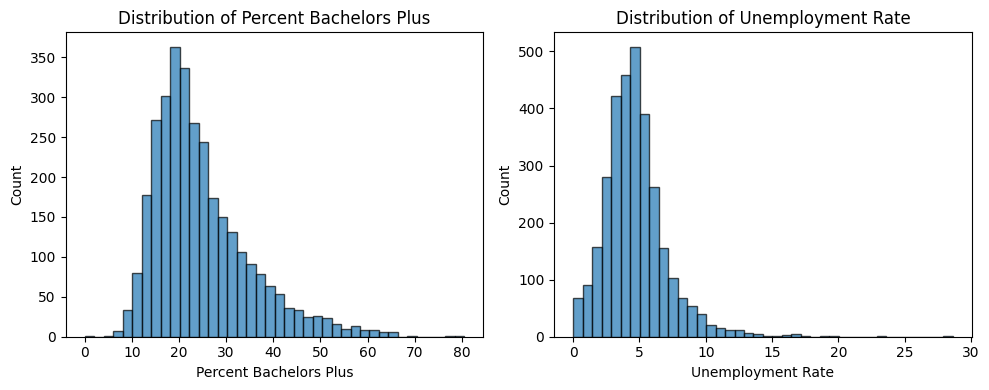

In [9]:
from src.viz import (
    histograms,
    scatter_education_unemployment,
    boxplot_unemployment_by_region,
)

OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

# Visualization 1: Histograms of main variables
histograms(df, output_dir=OUTPUTS_FIGURES)
plt.show()

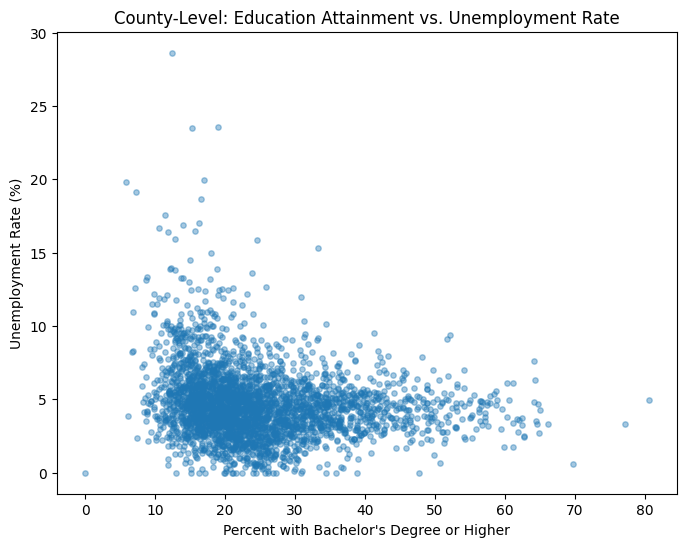

In [10]:
# Visualization 2: Scatter — education vs unemployment
scatter_education_unemployment(df, output_dir=OUTPUTS_FIGURES)
plt.show()

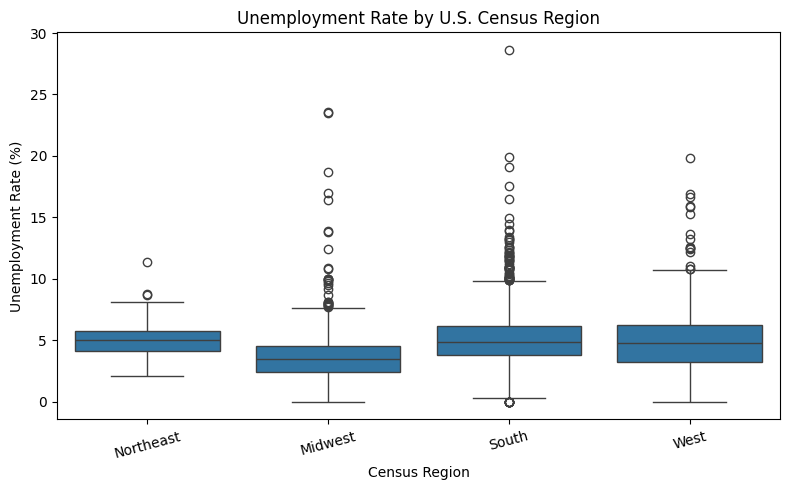

In [11]:
# Visualization 3: Boxplot — unemployment rate by region
boxplot_unemployment_by_region(df, output_dir=OUTPUTS_FIGURES)
plt.show()

## 5. Hypothesis Tests

### 5.1 Pearson correlation: Education vs. unemployment

**Research question:** Is county-level percent with bachelor's degree or higher significantly correlated with county-level unemployment rate?

**Test:** Pearson correlation (parametric). We assume approximate normality of the variables (or large n); the sample size (thousands of counties) supports the use of the correlation test.

- **H₀ (null):** There is no linear correlation between percent bachelor's+ and unemployment rate in the population (ρ = 0).
- **Hₐ (alternative):** There is a linear correlation (ρ ≠ 0).

In [12]:
x = df["percent_bachelors_plus"].dropna()
y = df["unemployment_rate"].dropna()
# Align by index for paired test
common = x.index.intersection(y.index)
x = x.loc[common]
y = y.loc[common]

r, p_value = stats.pearsonr(x, y)
print(f"Pearson correlation coefficient (r): {r:.4f}")
print(f"p-value (two-tailed): {p_value:.4e}")
print(f"Sample size (counties): {len(x)}")
if p_value < 0.05:
    print("Conclusion: We reject the null hypothesis at α = 0.05. There is statistically significant linear correlation.")
else:
    print("Conclusion: We do not reject the null hypothesis at α = 0.05.")

Pearson correlation coefficient (r): -0.1860
p-value (two-tailed): 7.0437e-26
Sample size (counties): 3144
Conclusion: We reject the null hypothesis at α = 0.05. There is statistically significant linear correlation.


### 5.2 One-way ANOVA: Unemployment rate by Census region

**Research question:** Does county-level unemployment rate differ significantly across U.S. Census regions?

**Test:** One-way ANOVA (parametric). We compare mean unemployment rate across the four Census regions (Northeast, Midwest, South, West). ANOVA is appropriate when the outcome is continuous and we have one categorical factor with multiple groups; we assume approximate normality and roughly equal variances across groups (sample sizes per region are large).

- **H₀ (null):** Mean unemployment rate is the same across all four Census regions (μ_Northeast = μ_Midwest = μ_South = μ_West).
- **Hₐ (alternative):** At least one region has a different mean unemployment rate.

In [13]:
order = ["Northeast", "Midwest", "South", "West"]
groups = [df[df["region"] == r]["unemployment_rate"].dropna().values for r in order]
f_stat, p_anova = stats.f_oneway(*groups)
n_by_region = [len(g) for g in groups]
print("One-way ANOVA: Unemployment rate by Census region")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_anova:.4e}")
print("Sample sizes by region:", dict(zip(order, n_by_region)))
if p_anova < 0.05:
    print("Conclusion: We reject H₀ at α = 0.05. Mean unemployment rate differs significantly across at least one pair of regions.")
else:
    print("Conclusion: We do not reject H₀ at α = 0.05.")

One-way ANOVA: Unemployment rate by Census region
F-statistic: 97.6073
p-value: 2.1110e-60
Sample sizes by region: {'Northeast': 218, 'Midwest': 1055, 'South': 1422, 'West': 449}
Conclusion: We reject H₀ at α = 0.05. Mean unemployment rate differs significantly across at least one pair of regions.


### Notebook Summary

This notebook explored county-level educational attainment and employment using ACS B15003 and B23025. We found a significant negative correlation between percent with a bachelor's degree or higher and unemployment rate, and significant differences in mean unemployment across U.S. Census regions (ANOVA). 

- **Data:** ACS 5-Year 2024 B15003 (educational attainment, population 25+) and B23025 (employment status, population 16+) at county level. Data loaded and merged on GEO_ID; derived variables: percent with bachelor's degree or higher, unemployment rate; added Census region.
- **Descriptive statistics:** Summary statistics and a summary by region (count and mean education/unemployment per region) were computed; Pearson correlation between education and unemployment is negative (higher education associated with lower unemployment).
- **Visualizations:** (1) Histograms of percent bachelor's+ and unemployment rate; (2) Scatter plot of education vs unemployment; (3) Boxplot of unemployment by Census region. All figures have titles and labeled axes.
- **Hypothesis tests:** (1) Pearson correlation test of H₀: ρ = 0 vs Hₐ: ρ ≠ 0 for education and unemployment—significant p-value, indicating a linear association. (2) One-way ANOVA of unemployment rate by Census region (H₀: equal means across regions)—significant p-value, indicating that mean unemployment differs across at least one pair of regions.
- **Challenges:** Census CSVs use two header rows and suppressed values (e.g. "-", "*****"); these were handled by skipping the second header and coercing to numeric (suppressed become NaN) and dropping missing for the analysis. Dropping counties with missing data may introduce selection bias if missingness is related to education or employment.